In [5]:
import atmPy.radiation.retrievals.broadband_shortwave_radiation as atmbsr
import atmPy.general.measurement_site as atmms
plt.rcParams['figure.dpi'] = 200

# 20180104/05

# short section

### load data and condition the data

In [1]:
# %matplotlib widget

In [2]:
%matplotlib inline

In [3]:
# read and condition the file
## read
fl = ['/Users/htelg/tmp/saildrone-gen4-tpos_2017-sd-1005-20180104T000000-20180104T235959-10hz-v1.1544089890356.nc', '/Users/htelg/tmp/saildrone-gen4-tpos_2017-sd-1005-20180105T000000-20180105T235959-10hz-v1.1544089821364.nc']
out = []
for p2f in fl:
    ds = xr.open_dataset(p2f)
    ds = ds.isel(trajectory = 0, drop = True)
    ds = ds.set_coords("time").swap_dims({"obs": "time"})
    out.append(ds)

ds = xr.concat(out, 'time')

In [4]:
reload(atmbsr)
reload(atmbsr.tiltcorrection)

NameError: name 'atmbsr' is not defined

In [6]:
# ds

In [7]:
ds = ds.where(~ds.SW_IRRAD_TOTAL.isnull(), 
         drop = True
        )

ds = ds.rename({'time': 'datetime'})

ds = ds.rename_vars({'SW_IRRAD_TOTAL': 'global_horizontal',
               'SW_IRRAD_DIFFUSE': 'diffuse_horizontal',
               'PITCH_WING': 'platform_pitch',
               'ROLL_WING': 'platform_roll',
               'HDG_WING': 'platform_heading',})

ds.global_horizontal.attrs['units'] = 'W/m^2'
ds.diffuse_horizontal.attrs['units'] = 'W/m^2'

ds['platform_pitch'] = np.deg2rad(ds.platform_pitch)
ds.platform_pitch.attrs['units'] = 'radian'
ds['platform_roll'] = np.deg2rad(ds.platform_roll)
ds.platform_roll.attrs['units'] = 'radian'
ds['platform_heading'] = np.deg2rad(ds.platform_heading)
ds.platform_heading.attrs['units'] = 'radian'

ds.platform_pitch.attrs['positive'] = 'nose-up'

ds.platform_roll.attrs['positive'] = 'right-side-down'

ds['altitude'] = xr.zeros_like(ds.platform_pitch)


# offsets
ds['platform_pitch'] += np.deg2rad(-8.3)
ds['platform_roll'] += np.deg2rad(-1)
dsfull = ds

## most of the day

In [156]:
# start = pd.to_datetime(matplotlib.dates.num2date(17535.973894827766)).tz_localize(None)
start = pd.to_datetime('2018-01-04 15:53:00')
# end = pd.to_datetime(matplotlib.dates.num2date(17535.974244202218)).tz_localize(None)
end = pd.to_datetime('2018-01-05 02:14:00')
# ds = ds.sel(time = slice(pd.to_datetime('2018-01-04 15:00:00'), pd.to_datetime('2018-01-05 03:00:00')), drop = True)
ds = dsfull.sel(datetime = slice(start, end), drop = True)

In [167]:
rin = atmbsr.CombinedGlobalDiffuseDirect(ds, verbose = True)
self = rin

out = rin.apply_tilt_correction()
out

mut = np.cos(rin.dataset.solar_incidence_angle)
mu0 = np.cos(rin.dataset.solar_zenith)
muperc = (mut-mu0)/mu0 * 100

In [158]:
rsd = {}
rss = [0.2, 
       #0.4,0.6, 0.8 
      ]
for rs in rss:
    rsd[rs] = rin.apply_tilt_correction(sensor_response_time=rs)

In [159]:
%matplotlib inline

Text(0.5, 0, '')

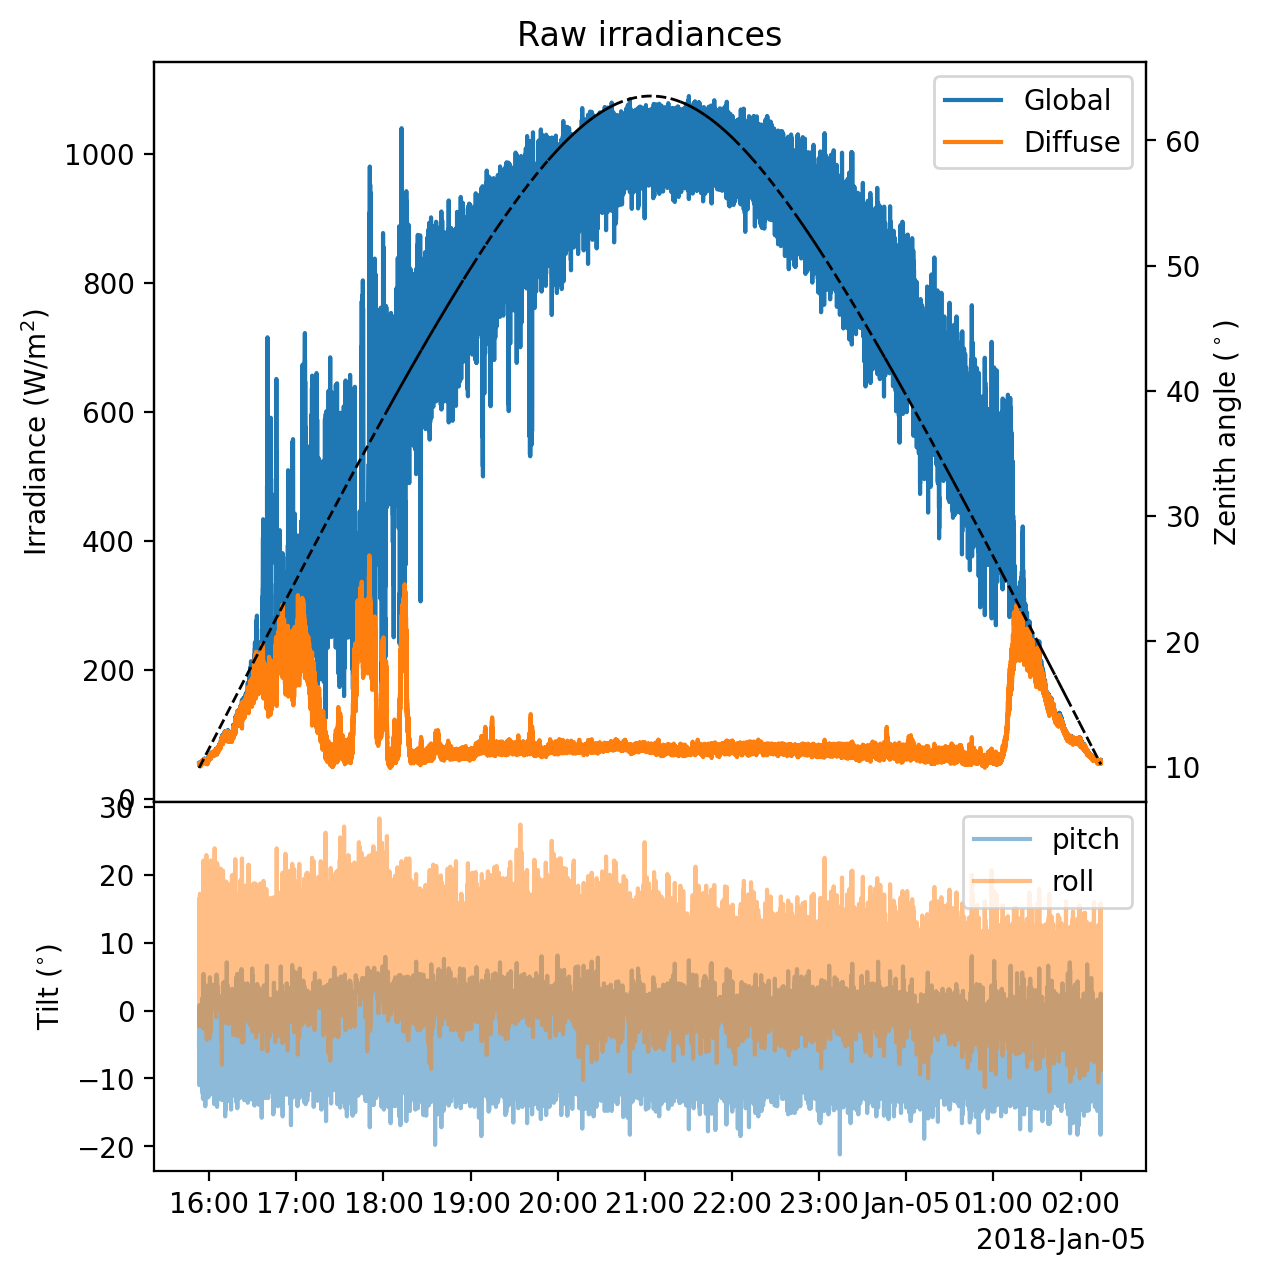

In [184]:
f,aa = plt.subplots(2,sharex=True, height_ratios=[2,1], gridspec_kw={'hspace': 0})

a = aa[0]
ds.global_horizontal.plot(ax = a, label = 'Global')
ds.diffuse_horizontal.plot(ax = a, label = 'Diffuse')

a.legend(
    # fontsize = 'x-small'
)
##
at = a.twinx()
(90-np.rad2deg(ds.solar_zenith)).plot(ax = at, color = 'black', lw = 1, ls = '--')
at.set_ylabel(r'Zenith angle ($^\circ$)')
# a.set_ylim(0,1018.8186483905149)



a.set_title('Raw irradiances')
a.set_xlabel('')
a.set_ylabel('Irradiance (W/m$^2$)')

##########
a = aa[1]
alpha = 0.5
np.rad2deg(ds.platform_pitch).plot(ax = a, alpha = alpha, label = 'pitch')
np.rad2deg(ds.platform_roll).plot(ax = a, alpha = alpha, label = 'roll')
# np.rad2deg(ds.platform_heading).plot(ax = a, alpha = alpha, label = 'heading')
a.set_ylabel(r'Tilt ($^{\circ}$)')
a.legend(
    # fontsize = 'small'
)
a.set_xlabel('')

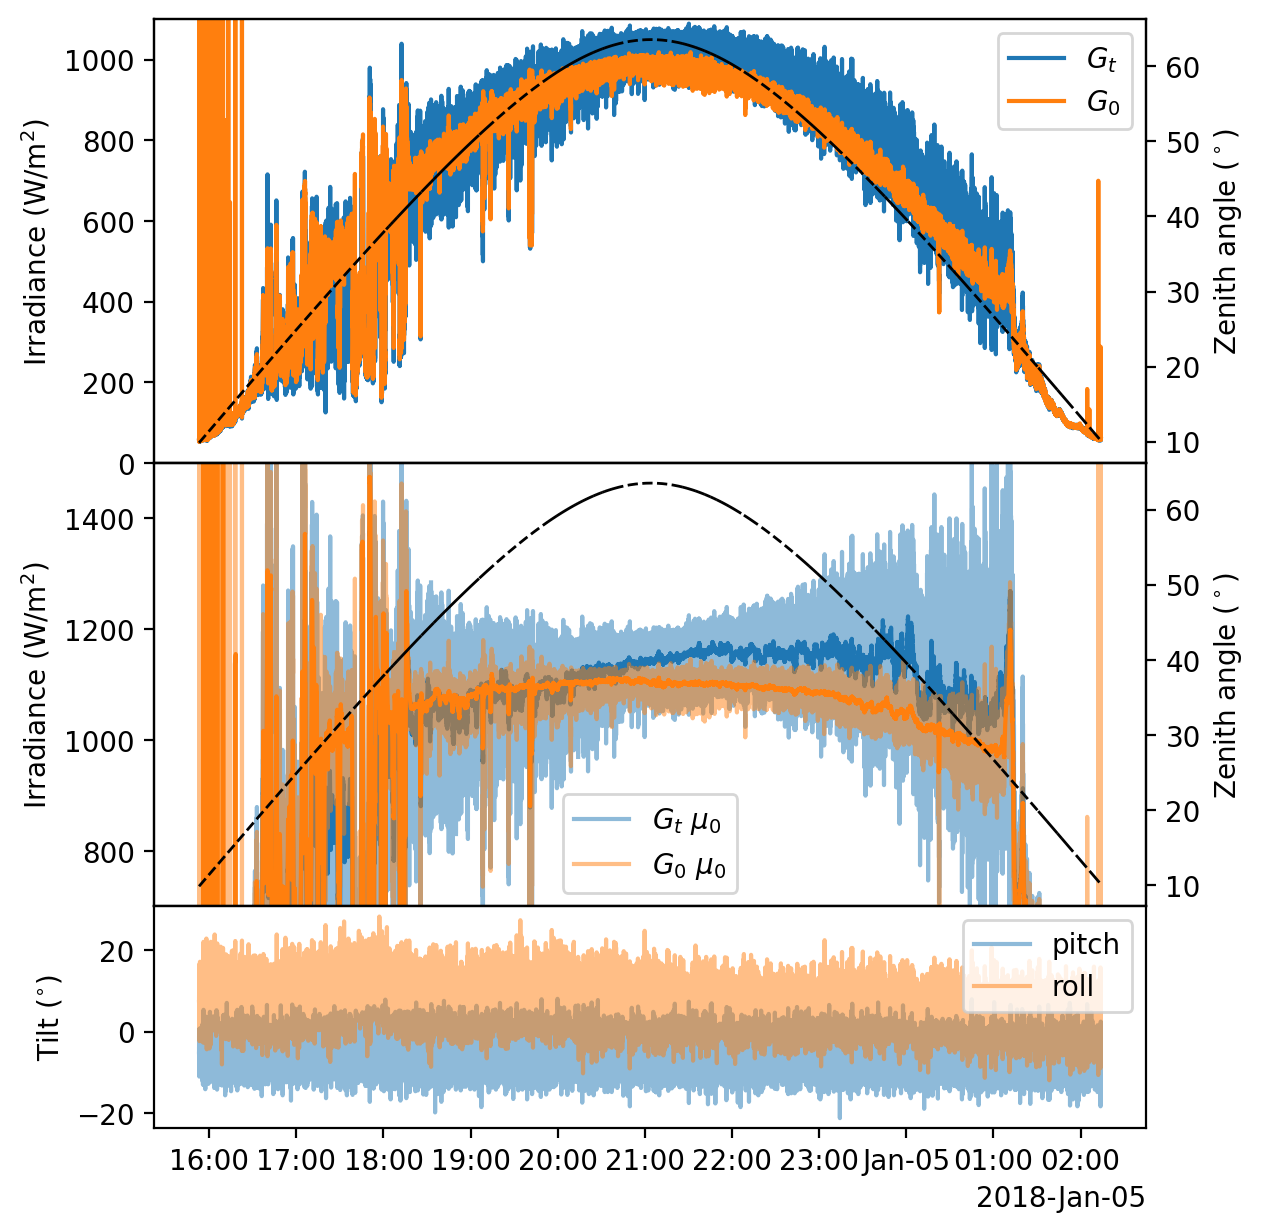

In [191]:
f,aa = plt.subplots(3,sharex=True, height_ratios=[2,2,1], gridspec_kw={'hspace': 0})
f.set_figheight(f.get_figheight() * 1.5)


a = aa[0]
ds.global_horizontal.plot(ax = a, label = '$G_t$')
# ds.diffuse_horizontal.plot(ax = a, label = 'Diffuse')
for rs in rsd:
    outt = rsd[rs]
    outt.dataset.global_horizontal.plot(ax = a, label = '$G_0$')
a.legend(
    # fontsize = 'x-small'
)
a.set_ylim(0,1100)
##
at = a.twinx()
(90-np.rad2deg(ds.solar_zenith)).plot(ax = at, color = 'black', lw = 1, ls = '--')
at.set_ylabel(r'Zenith angle ($^\circ$)')
# a.set_ylim(0,1018.8186483905149)



a.set_title('Raw irradiances')
a.set_xlabel('')
a.set_ylabel('Irradiance (W/m$^2$)')

###########
a = aa[1]
dst = ds.global_horizontal/ mu0
g1, = dst.plot(ax = a,  label = r'$G_t~\mu_0$')
dst.rolling(datetime = 200, center = True, min_periods=1).mean().plot(ax = a, color = g1.get_color())
g1.set_alpha(0.5)
# ds.diffuse_horizontal.plot(ax = a, label = 'Diffuse')
for rs in rsd:
    outt = rsd[rs]
    dst = outt.dataset.global_horizontal / mu0
    g1, = dst.plot(ax = a,  label = r'$G_0~\mu_0$')
    dst.rolling(datetime = 200, center = True, min_periods=1).mean().plot(ax = a, color = g1.get_color())
    g1.set_alpha(0.5)


a.legend(
    # fontsize = 'x-small'
)
a.set_ylim(700,1500)
##
at = a.twinx()
(90-np.rad2deg(ds.solar_zenith)).plot(ax = at, color = 'black', lw = 1, ls = '--')
at.set_ylabel(r'Zenith angle ($^\circ$)')
# a.set_ylim(0,1018.8186483905149)



a.set_title('Raw irradiances')
a.set_xlabel('')
a.set_ylabel('Irradiance (W/m$^2$)')
##########
a = aa[2]
alpha = 0.5
np.rad2deg(ds.platform_pitch).plot(ax = a, alpha = alpha, label = 'pitch')
np.rad2deg(ds.platform_roll).plot(ax = a, alpha = alpha, label = 'roll')
# np.rad2deg(ds.platform_heading).plot(ax = a, alpha = alpha, label = 'heading')
a.set_ylabel(r'Tilt ($^{\circ}$)')
a.legend(
    # fontsize = 'small'
)
a.set_xlabel('')


################
for a in aa:
    a.set_title('')

Text(0.5, 0, '')

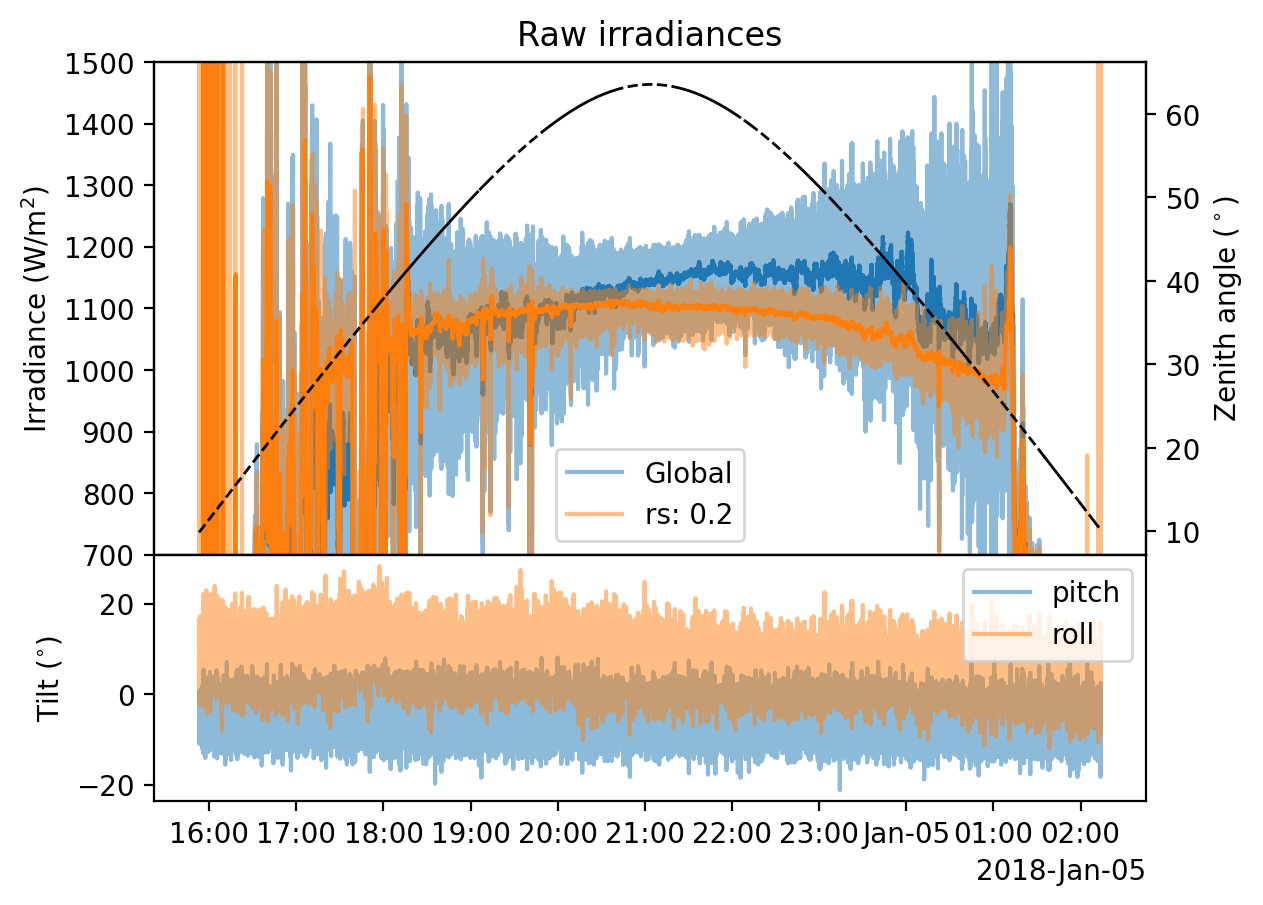

In [178]:
f,aa = plt.subplots(2,sharex=True, height_ratios=[2,1], gridspec_kw={'hspace': 0})

a = aa[0]
dst = ds.global_horizontal/ mu0
g1, = dst.plot(ax = a, label = 'Global')
dst.rolling(datetime = 200, center = True, min_periods=1).mean().plot(ax = a, color = g1.get_color())
g1.set_alpha(0.5)
# ds.diffuse_horizontal.plot(ax = a, label = 'Diffuse')
for rs in rsd:
    outt = rsd[rs]
    dst = outt.dataset.global_horizontal / mu0
    g1, = dst.plot(ax = a, label = f'rs: {rs}')
    dst.rolling(datetime = 200, center = True, min_periods=1).mean().plot(ax = a, color = g1.get_color())
    g1.set_alpha(0.5)


a.legend(
    # fontsize = 'x-small'
)
a.set_ylim(700,1500)
##
at = a.twinx()
(90-np.rad2deg(ds.solar_zenith)).plot(ax = at, color = 'black', lw = 1, ls = '--')
at.set_ylabel(r'Zenith angle ($^\circ$)')
# a.set_ylim(0,1018.8186483905149)



a.set_title('Raw irradiances')
a.set_xlabel('')
a.set_ylabel('Irradiance (W/m$^2$)')

##########
a = aa[1]
alpha = 0.5
np.rad2deg(ds.platform_pitch).plot(ax = a, alpha = alpha, label = 'pitch')
np.rad2deg(ds.platform_roll).plot(ax = a, alpha = alpha, label = 'roll')
# np.rad2deg(ds.platform_heading).plot(ax = a, alpha = alpha, label = 'heading')
a.set_ylabel(r'Tilt ($^{\circ}$)')
a.legend(
    # fontsize = 'small'
)
a.set_xlabel('')

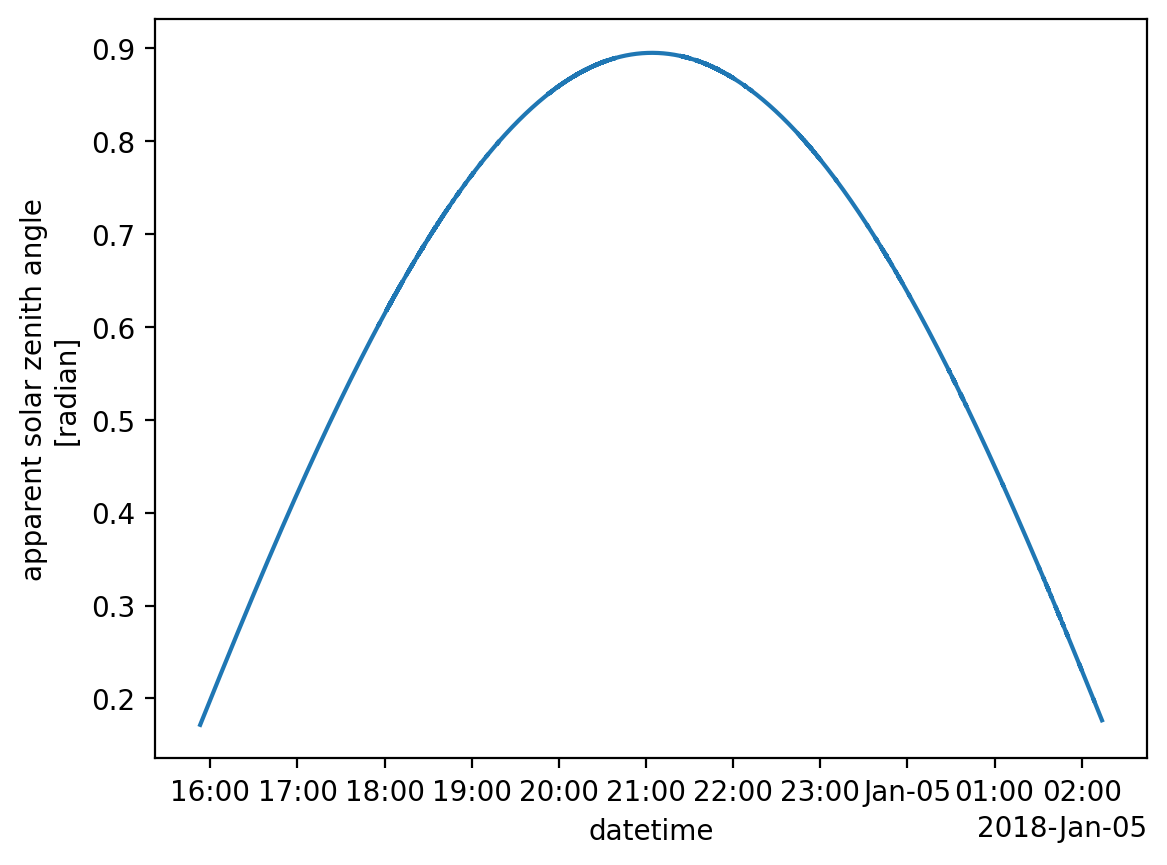

In [109]:
f,aa = plt.subplots(1,sharex=True, gridspec_kw={'hspace': 0})

a = aa
# ds.global_horizontal.plot(ax = a, label = 'raw')
# out.dataset.global_horizontal.plot(ax = a, label = 'instant')

for rs in rsd:
    outt = rsd[rs]
    # outt.dataset.global_horizontal.plot(ax = a, label = f'rs: {rs}')

diff = outt.dataset.global_horizontal - ds.global_horizontal
diff.plot(ax = a)
diff.rolling(datetime = 200, center = True, min_periods=1).mean().plot(ax = a)

a.legend(fontsize = 'x-small')
##
at = a.twinx()
(90-np.rad2deg(ds.solar_zenith)).plot(ax = at, color = 'black')

a.set_ylim(-300, 300)

# a.set_xlim(np.float64(17535.973894827766), np.float64(17535.974244202218))

# for a in aa:
a.set_title('')
a.set_xlabel('')
a.grid()

/var/folders/f4/dl3whmyd1rj_9smbyhmyqyj1h26f40/T/ipykernel_23889/1006237789.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  a.legend(fontsize = 'x-small')


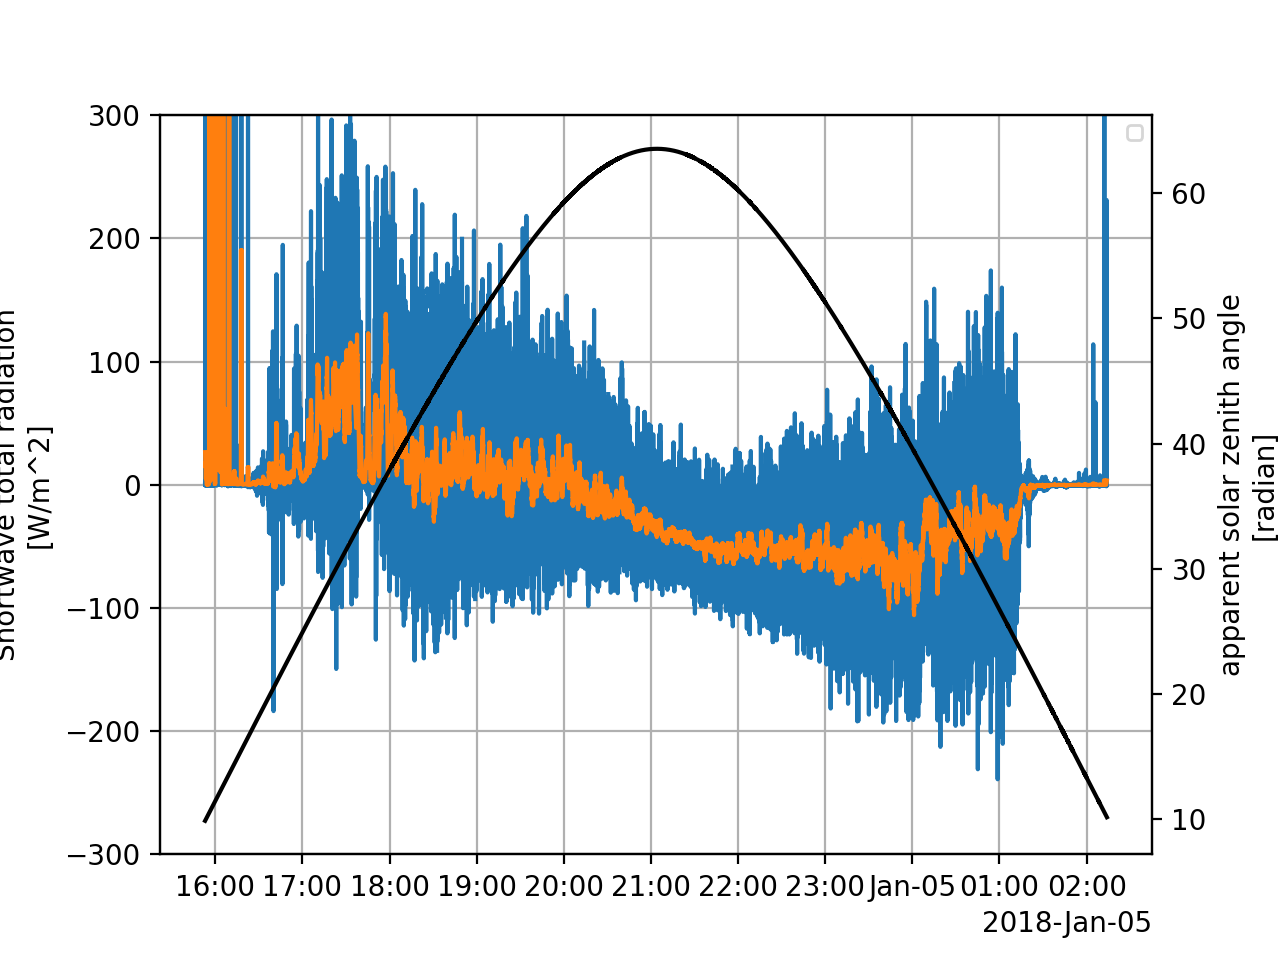

In [110]:
f.show()

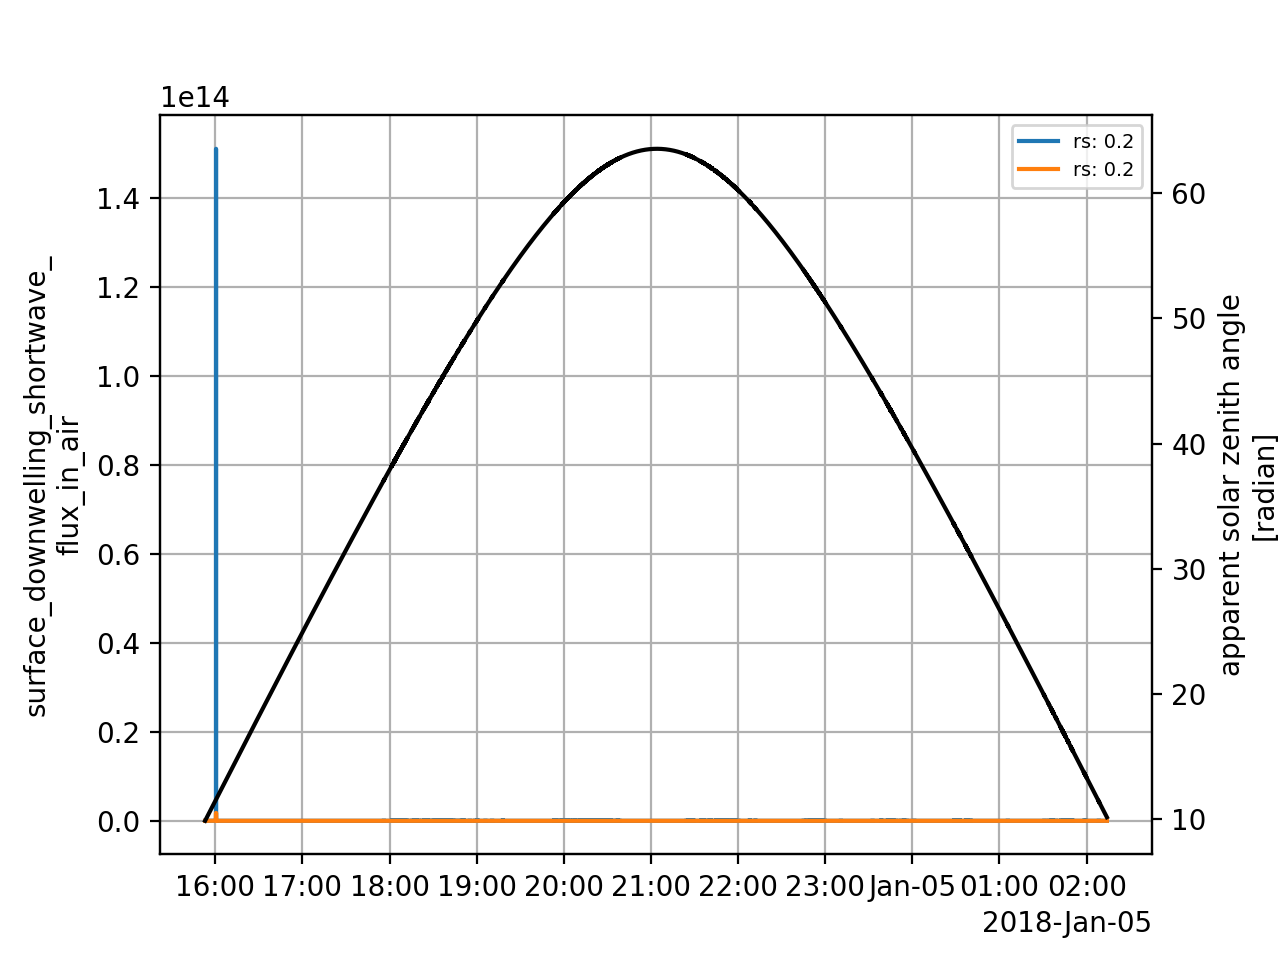

In [96]:
f.show()

## short time section

In [192]:
# select time
ds = dsfull.sel(datetime = slice(pd.to_datetime('2018-01-04 15:00:00'), pd.to_datetime('2018-01-05 03:00:00')), drop = True)

In [193]:
rin = atmbsr.CombinedGlobalDiffuseDirect(ds, verbose = True)
self = rin

out = rin.apply_tilt_correction()
out

mut = np.cos(rin.dataset.solar_incidence_angle)
mu0 = np.cos(rin.dataset.solar_zenith)
muperc = (mut-mu0)/mu0 * 100

No site provided, trying to infer site information from dataset.
Found latitude and longitude in dataset variables. Latitude and longitude are time dependent. Assuming moving platform.


In [194]:
rsd = {}
rss = [0.2, 
       #0.4,0.6, 0.8 
      ]
for rs in rss:
    rsd[rs] = rin.apply_tilt_correction(sensor_response_time=rs)

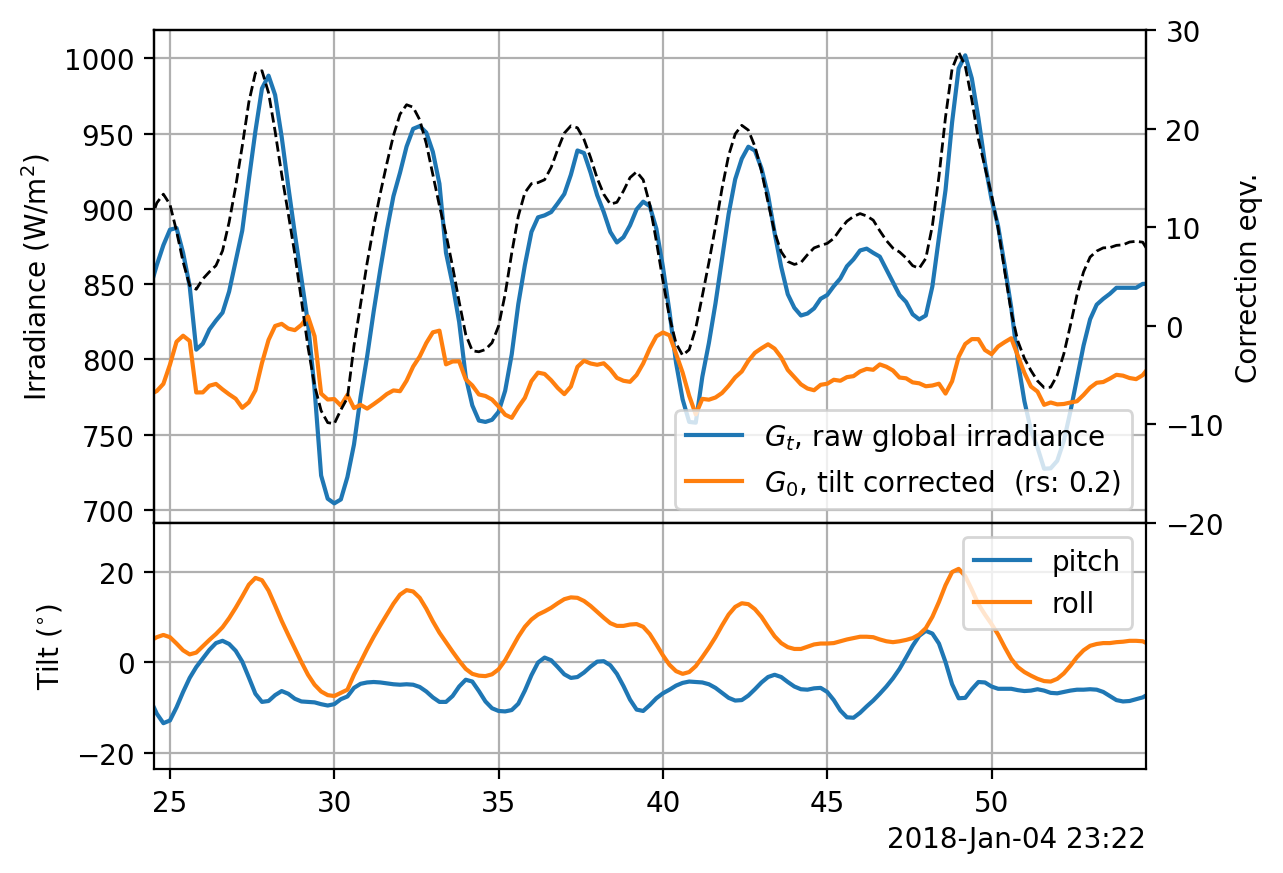

In [197]:
f,aa = plt.subplots(2,sharex=True, height_ratios=[2,1], gridspec_kw={'hspace': 0})

a = aa[0]
ds.global_horizontal.plot(ax = a, label = r'$G_{t}$, raw global irradiance')
# out.dataset.global_horizontal.plot(ax = a, label = 'instant')
for rs in rsd:
    outt = rsd[rs]
    outt.dataset.global_horizontal.plot(ax = a, label = r'$G_{0}$, tilt corrected  ' + f'(rs: {rs})')


a.legend(loc = 4,
         # fontsize = 'small'
        )
a.set_ylabel('Irradiance (W/m$^2$)')
##
at = a.twinx()
muperc.plot(ax = at, color = 'black', ls = '--', lw = 1)
at.set_ylim(-20,30)
at.set_ylabel(r'Correction eqv.')
##
# out.dataset.global_horizontal.where(muperc < 10).plot(ax = a, ls = '', marker = '.')
# ds.diffuse_horizontal.plot(ax = a)
a = aa[1]
np.rad2deg(ds.platform_pitch).plot(ax = a, label = 'pitch')
np.rad2deg(ds.platform_roll).plot(ax = a, label = 'roll')
# ds.platform_heading.plot(ax = a, marker = '.')
a.legend()
a.set_ylabel(r'Tilt ($^{\circ}$)')

#######
a = aa[0]
a.set_ylim(np.float64(691.4781854990188), np.float64(1018.8186483905149))
a.set_xlim(np.float64(17535.973894827766), np.float64(17535.974244202218))

for a in aa:
    a.set_title('')
    a.set_xlabel('')
    a.grid()

No site provided, trying to infer site information from dataset.
Found latitude and longitude in dataset variables. Latitude and longitude are time dependent. Assuming moving platform.


/Users/htelg/prog/atm-py/atmPy/general/measurement_site.py:1166: UserWarning: Non-finite path coordinates were ignored
  warnings.warn('Non-finite path coordinates were ignored')


(<Figure size 1280x960 with 1 Axes>, <GeoAxes: >)

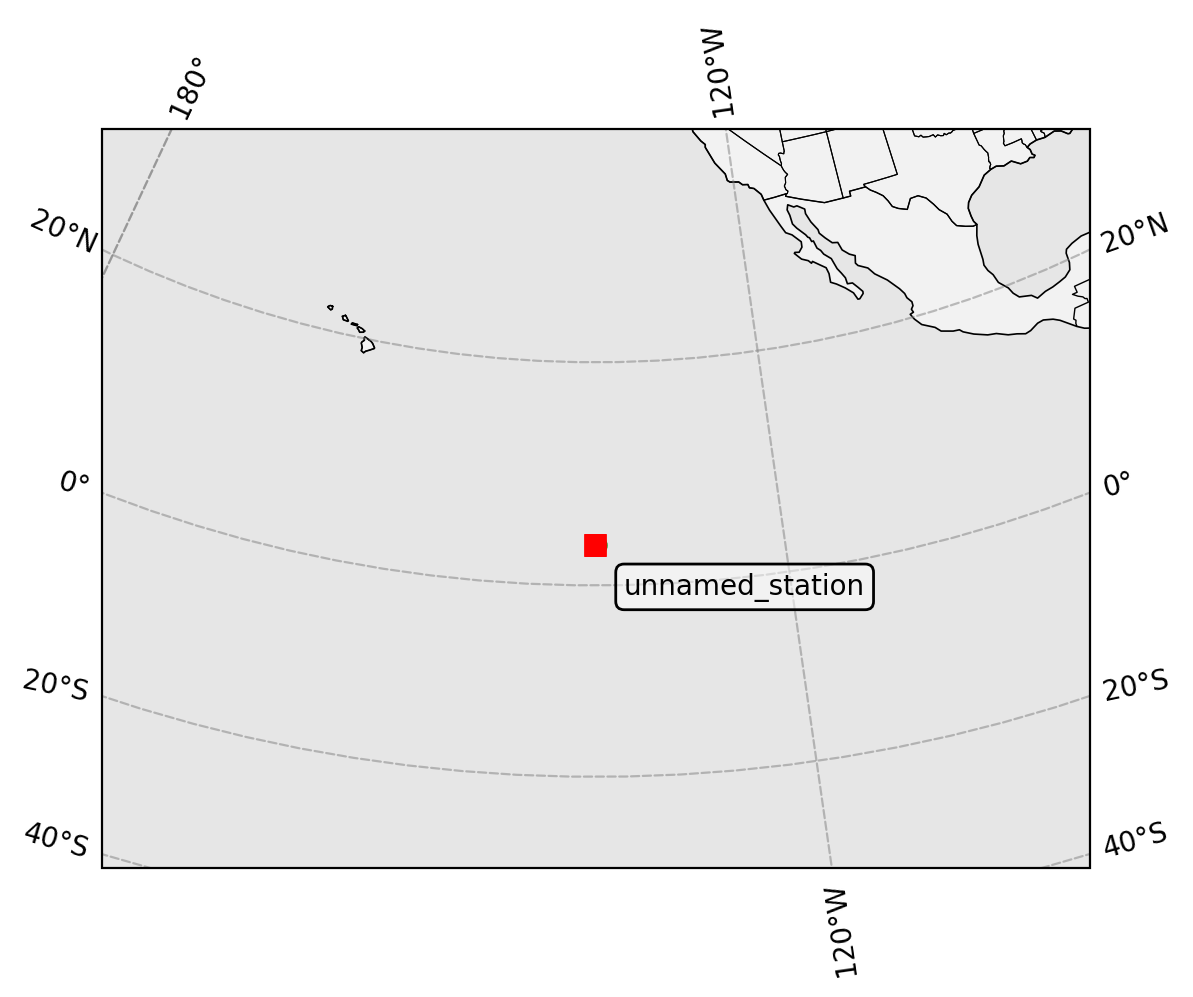

In [185]:
rin.site.plot_path(extent_pad=2**5, zoom_level=1)
# rin.sun_position

# determine instrument installation offsets

In [205]:
# start = pd.to_datetime(matplotlib.dates.num2date(17535.973894827766)).tz_localize(None)
start = pd.to_datetime('2018-01-04 18:22:00')
# end = pd.to_datetime(matplotlib.dates.num2date(17535.974244202218)).tz_localize(None)
end = pd.to_datetime('2018-01-04 23:59:00')
# ds = ds.sel(time = slice(pd.to_datetime('2018-01-04 15:00:00'), pd.to_datetime('2018-01-05 03:00:00')), drop = True)
ds = dsfull.sel(datetime = slice(start, end), drop = True)
# put the installation offsets back in
ds['platform_pitch'] -= np.deg2rad(-8.3)
ds['platform_roll'] -= np.deg2rad(-1)

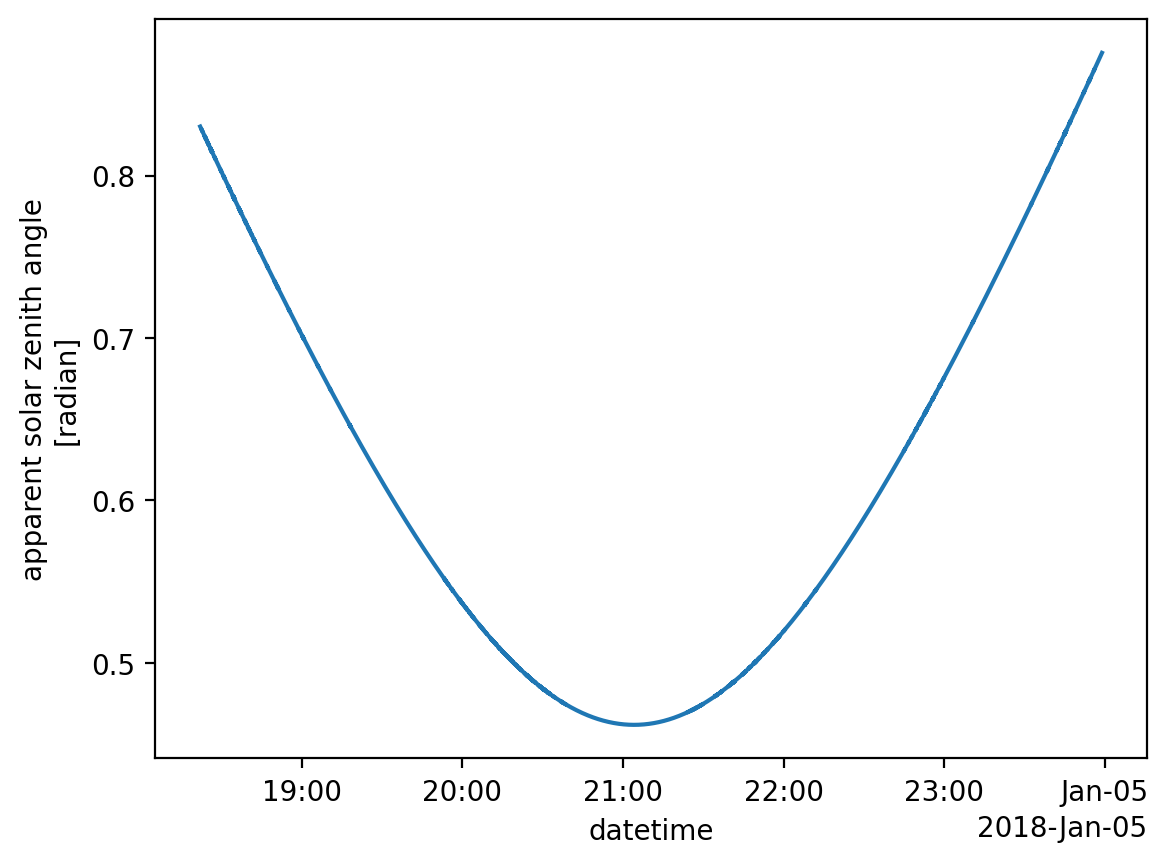

In [223]:
ds.solar_zenith.plot()

In [224]:
from scipy.optimize import minimize

def minthis(ds, dr, dp, dh, sensor_response_time=0.2, poly_order=3, verbose=False):
    dst = ds.copy()
    dst['platform_roll'] = dst.platform_roll + dr
    dst['platform_pitch'] = dst.platform_pitch + dp
    dst['platform_heading'] = dst.platform_heading + dh

    rin = atmbsr.CombinedGlobalDiffuseDirect(dst, verbose=verbose)
    out = rin.apply_tilt_correction(sensor_response_time=sensor_response_time)

    y = out.dataset.direct_normal
    dim = y.dims[0]
    x = y[dim]
    zenith_min_time = ds.solar_zenith.idxmin(dim=dim)
    if np.issubdtype(x.dtype, np.datetime64):
        xfit = (x - zenith_min_time) / np.timedelta64(1, 's')
    else:
        xfit = x - zenith_min_time

    yfit = y.values
    xfit = np.asarray(xfit.values, dtype=float)
    mask = np.isfinite(xfit) & np.isfinite(yfit)
    even_order = poly_order if poly_order % 2 == 0 else poly_order - 1
    powers = np.arange(0, even_order + 1, 2)
    design_matrix = np.column_stack([xfit[mask]**power for power in powers])
    coef, *_ = np.linalg.lstsq(design_matrix, yfit[mask], rcond=None)
    residual = yfit[mask] - design_matrix @ coef
    return float(np.std(residual))

def find_offset(ds, dr=None, dp=None, dh=None):
    """ Very experimental! Find installation offsets that minimize direct-normal irradiance variability.
    Note, this only works for moving platforms and mostly clearsky days. You will actuall
    need roll, pitch and heading to permanently change to get a result. 

    Parameters
    ----------
    ds : xarray.Dataset
        Dataset with platform_roll, platform_pitch, platform_heading,
        global_horizontal, and diffuse_horizontal variables.
    dr, dp, dh : float or None, optional
        Roll, pitch, and heading offsets in radians. If an offset is None, it is
        optimized. If an offset is provided, that value is held fixed and is not
        optimized.

    Returns
    -------
    pandas.Series
        Best offsets in radians and degrees, the minimized direct-normal
        standard deviation, and scipy optimization status fields.
    """
    # Search offsets in radians, but define/report them in degrees for readability.
    offset_names = ['dr', 'dp', 'dh']
    provided_offsets = {'dr': dr, 'dp': dp, 'dh': dh}
    free_offsets = [name for name in offset_names if provided_offsets[name] is None]
    bounds_deg = {name: (-15, 15) for name in offset_names}
    bounds = [tuple(np.deg2rad(v) for v in bounds_deg[name]) for name in free_offsets]
    optimization_trace = []

    def build_offsets(x):
        offsets = provided_offsets.copy()
        for name, value in zip(free_offsets, x):
            offsets[name] = value
        return offsets

    def objective(x):
        offsets = build_offsets(x)
        value = minthis(
            ds,
            offsets['dr'],
            offsets['dp'],
            offsets['dh'],
            sensor_response_time=0.2,
            verbose=False,
        )
        optimization_trace.append({
            'dr': offsets['dr'],
            'dp': offsets['dp'],
            'dh': offsets['dh'],
            'value': value,
        })
        return value

    if free_offsets:
        opt = minimize(
            objective,
            x0=np.zeros(len(free_offsets)),
            method='Powell',
            bounds=bounds,
            options={'xtol': 1e-4, 'ftol': 1e-4, 'disp': True},
        )
        best_offsets = build_offsets(opt.x)
        direct_normal_std = opt.fun
        success = opt.success
        message = opt.message
    else:
        best_offsets = provided_offsets
        direct_normal_std = objective([])
        success = True
        message = 'No offsets optimized; used provided values.'

    best = pd.Series({
        'dr_rad': best_offsets['dr'],
        'dp_rad': best_offsets['dp'],
        'dh_rad': best_offsets['dh'],
        'dr_deg': np.rad2deg(best_offsets['dr']),
        'dp_deg': np.rad2deg(best_offsets['dp']),
        'dh_deg': np.rad2deg(best_offsets['dh']),
        'direct_normal_std': direct_normal_std,
        'success': success,
        'message': message,
    })

    return best
find_offset(ds, dh = 0)

Optimization terminated successfully.
         Current function value: 24.128584
         Iterations: 4
         Function evaluations: 92


dr_rad                                            0.012004
dp_rad                                           -0.213278
dh_rad                                                   0
dr_deg                                            0.687794
dp_deg                                           -12.21992
dh_deg                                                 0.0
direct_normal_std                                24.128584
success                                               True
message              Optimization terminated successfully.
dtype: object

In [225]:
rin = atmbsr.CombinedGlobalDiffuseDirect(ds, verbose = True)
out = rin.apply_tilt_correction(sensor_response_time=0.2)

In [226]:
dsb = ds.copy()
dsb['platform_roll'] = ds.platform_roll + best['dr_rad']
dsb['platform_pitch'] = ds.platform_pitch + best['dp_rad']
dsb['platform_heading'] = ds.platform_heading + best['dh_rad']
rinb = atmbsr.CombinedGlobalDiffuseDirect(dsb, verbose = True)
outb = rinb.apply_tilt_correction(sensor_response_time=0.2)

In [227]:
float(out.dataset.direct_normal.std()),float(outb.dataset.direct_normal.std())

(63.37883698243485, 36.95196261434051)

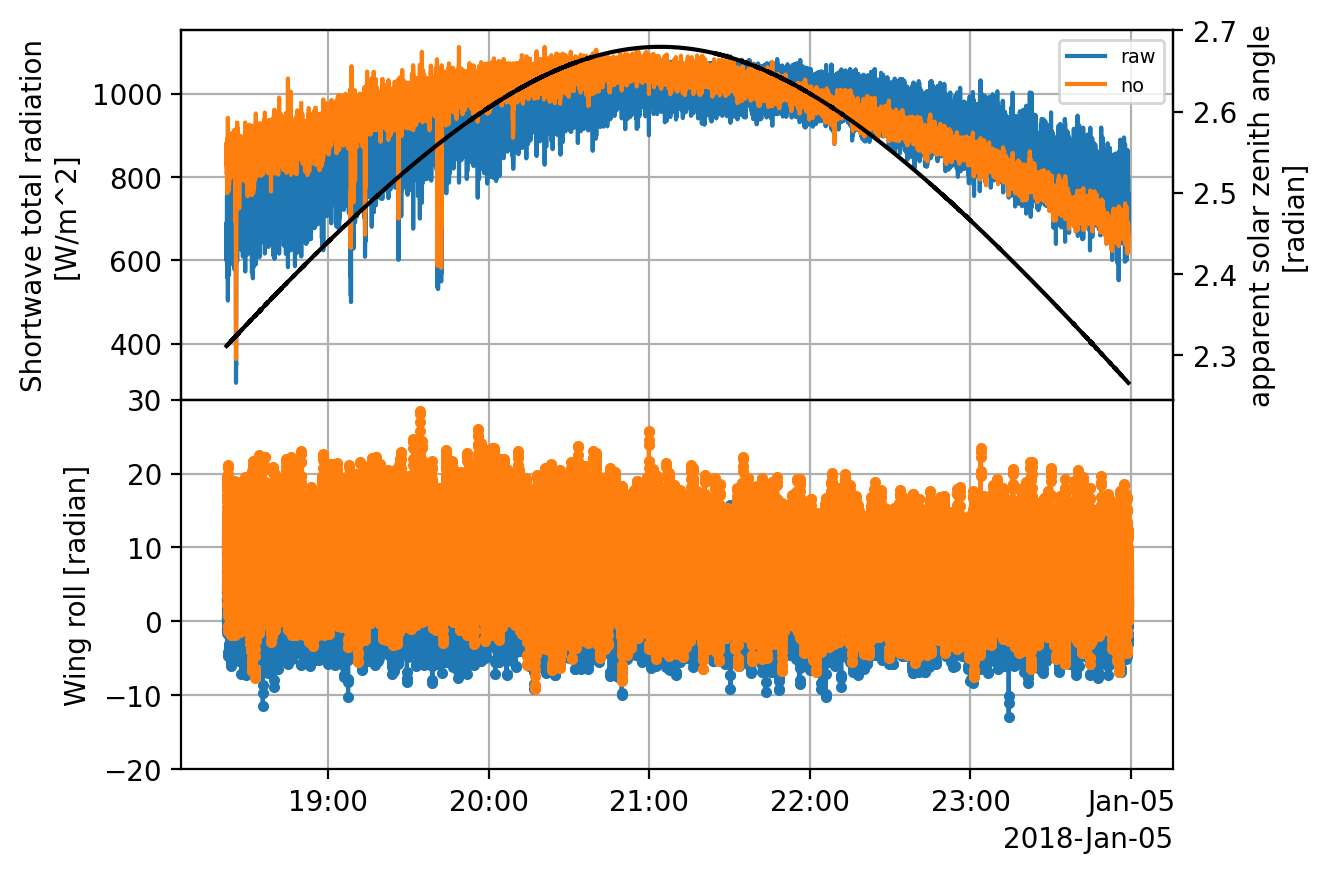

In [228]:
f,aa = plt.subplots(2,sharex=True, gridspec_kw={'hspace': 0})

a = aa[0]
ds.global_horizontal.plot(ax = a, label = 'raw')
out.dataset.global_horizontal.plot(ax = a, label = 'no')
# outb.dataset.global_horizontal.plot(ax = a, label = 'offsets')
# out3.dataset.global_horizontal.plot(ax = a, label = 'with responds time 2')



a.legend(fontsize = 'x-small')
##
at = a.twinx()
(np.pi - ds.solar_zenith).plot(ax = at, color = 'black')

# for dt in dtd:
#     outt = dtd[dt]
#     mut = outt.dataset.mut
#     mu0 = outt.dataset.mu0
#     muperc = (mut-mu0)/mu0 * 100
#     muperc.plot(ax = at, color = 'black', ls = '--')
#     break
# at.set_ylim(-20,30)
##
# out.dataset.global_horizontal.where(muperc < 10).plot(ax = a, ls = '', marker = '.')
# ds.diffuse_horizontal.plot(ax = a)
a = aa[1]
np.rad2deg(ds.platform_pitch).plot(ax = a, marker = '.')
np.rad2deg(ds.platform_roll).plot(ax = a, marker = '.')
# ds.platform_heading.plot(ax = a, marker = '.')
#######
# zenith vs incidence
# a = aa[2]
# rin.dataset.solar_zenith.plot(ax = a)
# rin.dataset.solar_incidence_angle.plot(ax = a)
# np.cos(rin.dataset.solar_zenith).plot(ax = a)
# np.cos(rin.dataset.solar_incidence_angle).plot(ax = a)

# muperc.plot(ax = a)
a.set_ylim(-20,30)

#######
a = aa[0]
# a.set_ylim(np.float64(691.4781854990188), np.float64(1018.8186483905149))
# a.set_xlim(np.float64(17535.973894827766), np.float64(17535.974244202218))

for a in aa:
    a.set_title('')
    a.set_xlabel('')
    a.grid()

## old

In [206]:
from scipy.optimize import minimize

def minthis(ds, dr, dp, dh, sensor_response_time=0.2, poly_order=3, verbose=False):
    dst = ds.copy()
    dst['platform_roll'] = dst.platform_roll + dr
    dst['platform_pitch'] = dst.platform_pitch + dp
    dst['platform_heading'] = dst.platform_heading + dh

    rin = atmbsr.CombinedGlobalDiffuseDirect(dst, verbose=verbose)
    out = rin.apply_tilt_correction(sensor_response_time=sensor_response_time)

    y = out.dataset.direct_normal
    dim = y.dims[0]
    x = y[dim]
    if np.issubdtype(x.dtype, np.datetime64):
        xfit = (x - x[0]) / np.timedelta64(1, 's')
    else:
        xfit = x

    yfit = y.values
    xfit = np.asarray(xfit.values, dtype=float)
    mask = np.isfinite(xfit) & np.isfinite(yfit)
    poly = np.polyfit(xfit[mask], yfit[mask], poly_order)
    residual = yfit[mask] - np.polyval(poly, xfit[mask])
    return float(np.std(residual))


# Search offsets in radians, but define/report them in degrees for readability.
bounds_deg = [(-10, 10), (-10, 10), (-10, 10)]
bounds = [(np.deg2rad(lo), np.deg2rad(hi)) for lo, hi in bounds_deg]

optimization_trace = []

def objective(x):
    value = minthis(ds, *x, sensor_response_time=0.2, verbose=False)
    optimization_trace.append({
        'dr': x[0],
        'dp': x[1],
        'dh': x[2],
        'value': value,
    })
    return value

opt = minimize(
    objective,
    x0=np.zeros(3),
    method='Powell',
    bounds=bounds,
    options={'xtol': 1e-4, 'ftol': 1e-4, 'disp': True},
)

best = pd.Series({
    'dr_rad': opt.x[0],
    'dp_rad': opt.x[1],
    'dh_rad': opt.x[2],
    'dr_deg': np.rad2deg(opt.x[0]),
    'dp_deg': np.rad2deg(opt.x[1]),
    'dh_deg': np.rad2deg(opt.x[2]),
    'direct_normal_std': opt.fun,
    'success': opt.success,
    'message': opt.message,
})

best

Optimization terminated successfully.
         Current function value: 24.089514
         Iterations: 3
         Function evaluations: 228


dr_rad                                            -0.06418
dp_rad                                           -0.174533
dh_rad                                            0.083718
dr_deg                                           -3.677218
dp_deg                                               -10.0
dh_deg                                            4.796685
direct_normal_std                                24.089514
success                                               True
message              Optimization terminated successfully.
dtype: object

In [207]:
rin = atmbsr.CombinedGlobalDiffuseDirect(ds, verbose = True)
out = rin.apply_tilt_correction(sensor_response_time=0.2)

No site provided, trying to infer site information from dataset.
Found latitude and longitude in dataset variables. Latitude and longitude are time dependent. Assuming moving platform.


In [208]:
dsb = ds.copy()
dsb['platform_roll'] = ds.platform_roll + best['dr_rad']
dsb['platform_pitch'] = ds.platform_pitch + best['dp_rad']
dsb['platform_heading'] = ds.platform_heading + best['dh_rad']
rinb = atmbsr.CombinedGlobalDiffuseDirect(dsb, verbose = True)
outb = rinb.apply_tilt_correction(sensor_response_time=0.2)

In [209]:
float(out.dataset.direct_normal.std()),float(outb.dataset.direct_normal.std())

(63.37883698243485, 36.95196261434051)

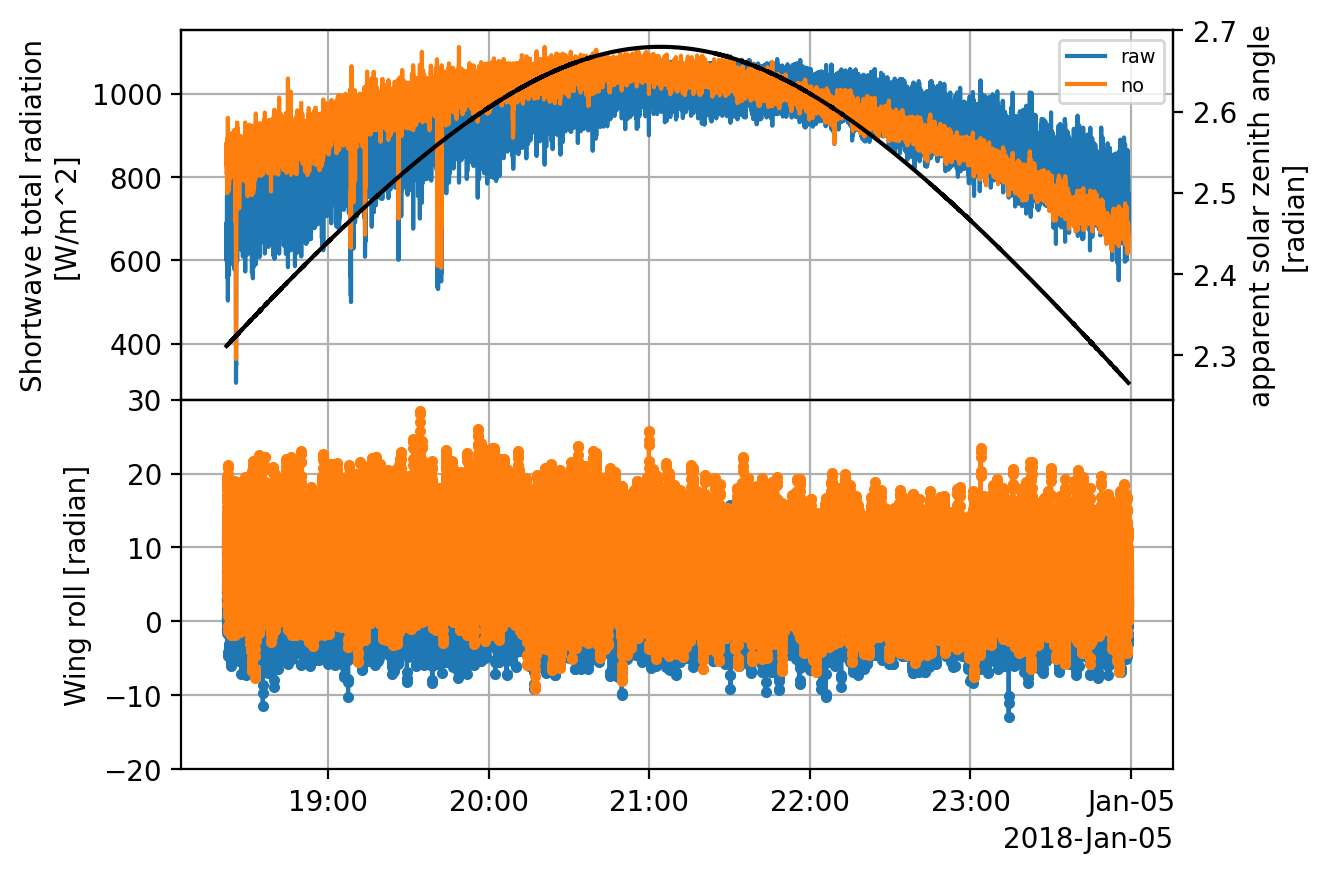

In [210]:
f,aa = plt.subplots(2,sharex=True, gridspec_kw={'hspace': 0})

a = aa[0]
ds.global_horizontal.plot(ax = a, label = 'raw')
out.dataset.global_horizontal.plot(ax = a, label = 'no')
# outb.dataset.global_horizontal.plot(ax = a, label = 'offsets')
# out3.dataset.global_horizontal.plot(ax = a, label = 'with responds time 2')



a.legend(fontsize = 'x-small')
##
at = a.twinx()
(np.pi - ds.solar_zenith).plot(ax = at, color = 'black')

# for dt in dtd:
#     outt = dtd[dt]
#     mut = outt.dataset.mut
#     mu0 = outt.dataset.mu0
#     muperc = (mut-mu0)/mu0 * 100
#     muperc.plot(ax = at, color = 'black', ls = '--')
#     break
# at.set_ylim(-20,30)
##
# out.dataset.global_horizontal.where(muperc < 10).plot(ax = a, ls = '', marker = '.')
# ds.diffuse_horizontal.plot(ax = a)
a = aa[1]
np.rad2deg(ds.platform_pitch).plot(ax = a, marker = '.')
np.rad2deg(ds.platform_roll).plot(ax = a, marker = '.')
# ds.platform_heading.plot(ax = a, marker = '.')
#######
# zenith vs incidence
# a = aa[2]
# rin.dataset.solar_zenith.plot(ax = a)
# rin.dataset.solar_incidence_angle.plot(ax = a)
# np.cos(rin.dataset.solar_zenith).plot(ax = a)
# np.cos(rin.dataset.solar_incidence_angle).plot(ax = a)

# muperc.plot(ax = a)
a.set_ylim(-20,30)

#######
a = aa[0]
# a.set_ylim(np.float64(691.4781854990188), np.float64(1018.8186483905149))
# a.set_xlim(np.float64(17535.973894827766), np.float64(17535.974244202218))

for a in aa:
    a.set_title('')
    a.set_xlabel('')
    a.grid()